In [47]:
import pandas as pd
from matplotlib import pyplot as plt

In [48]:
df=pd.read_csv("3.4_AnalysisShoeSales(UsingMeanMedianPercentile)_shoe_sales.csv")
df.head()

,date,brand,sold_qty
0,09-01-2023,Nike,24.0
1,09-01-2023,Adidas,14.0
2,09-02-2023,Nike,21.0
3,09-02-2023,Adidas,12.0
4,09-03-2023,Nike,18.0


In [49]:
df.shape()

TypeError: 'tuple' object is not callable

In [ ]:
df.describe()

In [50]:
df[df.sold_qty<12.25].shape

(15, 3)

In [51]:
15/60

0.25

### (1) NIKE ANALYSIS

In [52]:
df_nike = df[df.brand=="Nike"]
df_nike.shape

(30, 3)

In [53]:
df_nike.describe()

,sold_qty
count,28.000000
mean,19.642857
std,3.117624
min,14.000000
25%,17.000000
50%,19.500000
75%,22.000000
max,25.000000


In [54]:
df_nike.sold_qty.median()

np.float64(19.5)

In [55]:
round(df_nike.sold_qty.median())

20

In [56]:
df_nike.isnull()

,date,brand,sold_qty
0,False,False,False
2,False,False,False
4,False,False,False
6,False,False,False
8,False,False,False
10,False,False,False
12,False,False,False
14,False,False,False
16,False,False,False
18,False,False,False


In [57]:
df_nike[df_nike.sold_qty.isnull()]

,date,brand,sold_qty
32,9/17/2023,Nike,NaN
48,9/25/2023,Nike,NaN


In [58]:
val = round(df_nike.sold_qty.median())
val

20

In [59]:
# df_nike.fillna({"sold_qty":val},inplace=True)
df_nike.sold_qty.fillna(val,inplace=True)

C:\Users\yoges\AppData\Local\Temp\ipykernel_7756\1948899722.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_nike.sold_qty.fillna(val,inplace=True)


0     24.0
2     21.0
4     18.0
6     22.0
8     20.0
10    23.0
12    19.0
14    17.0
16    25.0
18    14.0
20    23.0
22    19.0
24    16.0
26    22.0
28    17.0
30    21.0
32    20.0
34    18.0
36    15.0
38    24.0
40    24.0
42    16.0
44    20.0
46    15.0
48    20.0
50    19.0
52    22.0
54    21.0
56    17.0
58    18.0
Name: sold_qty, dtype: float64

In [60]:
df_nike.fillna({"sold_qty":val},inplace=True)

,date,brand,sold_qty
0,09-01-2023,Nike,24.0
2,09-02-2023,Nike,21.0
4,09-03-2023,Nike,18.0
6,09-04-2023,Nike,22.0
8,09-05-2023,Nike,20.0
10,09-06-2023,Nike,23.0
12,09-07-2023,Nike,19.0
14,09-08-2023,Nike,17.0
16,09-09-2023,Nike,25.0
18,09-10-2023,Nike,14.0


In [61]:
df_nike.loc[[32,48]]

,date,brand,sold_qty
32,9/17/2023,Nike,20.0
48,9/25/2023,Nike,20.0


In [62]:
df_nike.sold_qty.sum()

np.float64(590.0)

### Adidas Analysis

In [63]:
df_adidas = df[df.brand=="Adidas"]
df_adidas

,date,brand,sold_qty
1,09-01-2023,Adidas,14.0
3,09-02-2023,Adidas,12.0
5,09-03-2023,Adidas,11.0
7,09-04-2023,Adidas,13.0
9,09-05-2023,Adidas,10.0
11,09-06-2023,Adidas,15.0
13,09-07-2023,Adidas,16.0
15,09-08-2023,Adidas,8.0
17,09-09-2023,Adidas,17.0
19,09-10-2023,Adidas,7.0


In [64]:
df_adidas.shape

(30, 3)

In [65]:
df_adidas.describe()

,sold_qty
count,30.000000
mean,34.800000
std,123.602366
min,7.000000
25%,10.000000
50%,12.500000
75%,15.000000
max,689.000000


In [66]:
df_adidas.sold_qty.median()

np.float64(12.5)

In [67]:
df_adidas.sold_qty.sum()

np.float64(1044.0)

In [68]:
df_adidas.sold_qty.quantile([0.95])

0.95    18.55
Name: sold_qty, dtype: float64

In [69]:
df_adidas[df_adidas.sold_qty>18.55]

,date,brand,sold_qty
23,09-12-2023,Adidas,689.0
39,9/20/2023,Adidas,19.0


In [70]:
def plot_qty():
    plt.figure(figsize=(15, 6))
    
    dates = df_nike['date']
    
    plt.plot(dates, df_nike['sold_qty'], marker='o', label='Nike', color='blue')
    plt.plot(dates, df_adidas['sold_qty'], marker='o', label='Adidas', color='red')
    
    plt.xlabel('Date')
    plt.ylabel('Total Qty Sold')
    plt.title('Daily Sales Qty for Nike and Adidas in September 2023')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

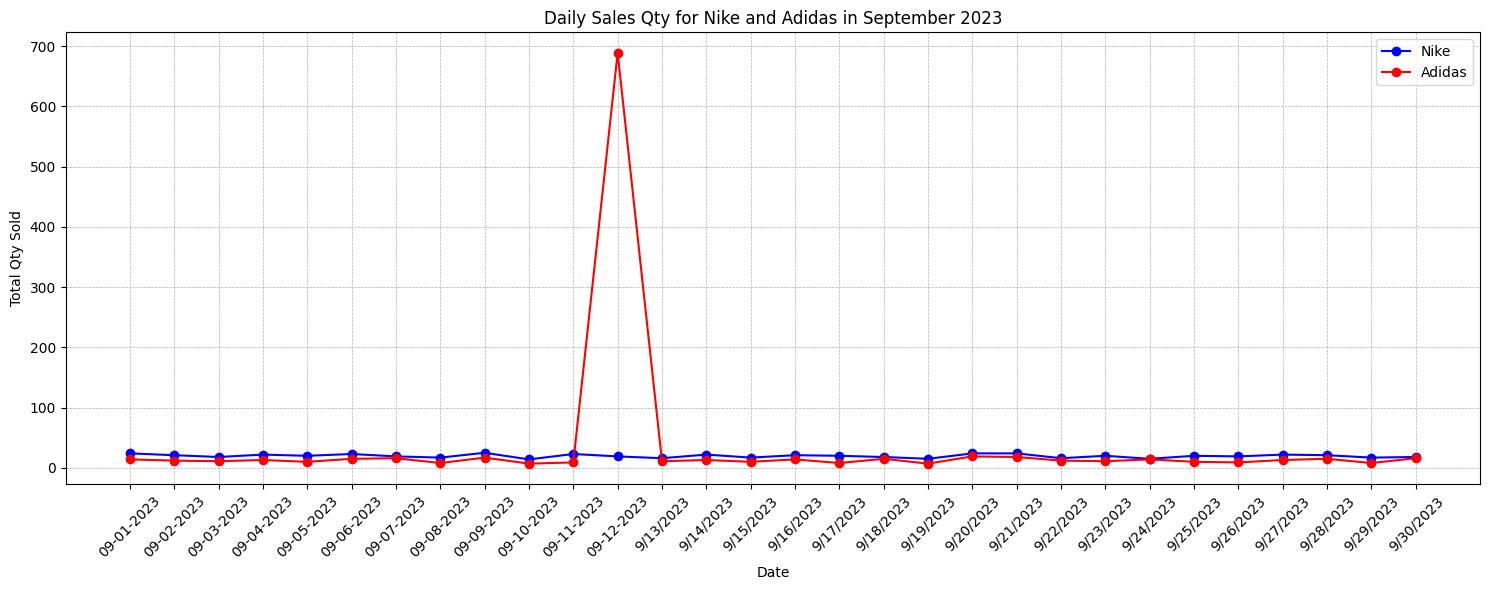

In [71]:
plot_qty()

In [72]:
val = round(df_adidas.sold_qty.median())
val

12

In [77]:
df_adidas['sold_qty'] = df_adidas['sold_qty'].replace(689, val)

In [78]:
df_adidas[df_adidas.sold_qty>18.55]

,date,brand,sold_qty
39,9/20/2023,Adidas,19.0


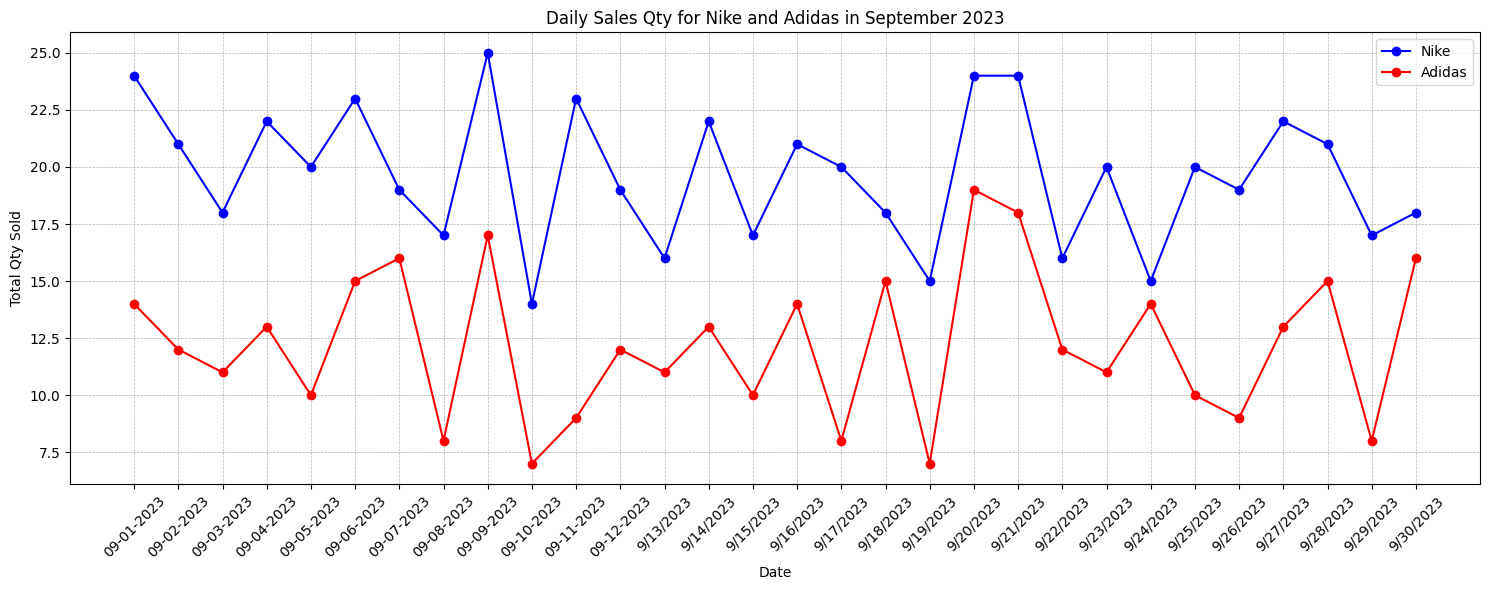

In [79]:
plot_qty()